In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Loading Data

In [2]:
img_path = "Image_Text_Z/VAI_HW_CLIP_Image_Vecs.csv"
txt_path = "Image_Text_Z/VAI_HW_CLIP_Text_Vecs.csv"

img_data = pd.read_csv(img_path, header=None).values.astype(np.float32)
txt_data = pd.read_csv(txt_path, header=None).values.astype(np.float32)

print("Image vectors shape:", img_data.shape)
print("Text vectors shape :", txt_data.shape)

assert img_data.shape[0] == txt_data.shape[0], "Image/Text row count must match"

N = img_data.shape[0]
img_dim = img_data.shape[1]
txt_dim = txt_data.shape[1]

# If rows are ordered as digit 0, then 1, then 2:
# this is only for later visualization / interpretation
labels = np.array([0]*100 + [1]*100 + [2]*100)



img_tensor = torch.tensor(img_data).to(device)
txt_tensor = torch.tensor(txt_data).to(device)

shared_dim = 128   # size of common embedding space

Image vectors shape: (300, 1568)
Text vectors shape : (300, 3072)


### Image NN

In [3]:
class ImageNet(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )

    def forward(self, x):
        return self.net(x)
img_model = ImageNet(img_dim, shared_dim).to(device)

### Text NN

In [4]:
class TextNet(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )

    def forward(self, x):
        return self.net(x)

txt_model = TextNet(txt_dim, shared_dim).to(device)

### Helper Function

In [5]:
def contrastive_clip_loss(czi, czt, temperature=0.07):
    """
    czi: transformed image vectors  shape = (N, D)
    czt: transformed text vectors   shape = (N, D)

    Steps:
    1) L2 normalize both
    2) compute cosine similarity matrix
    3) divide by temperature
    4) image->text CE loss
    5) text->image CE loss
    6) average the two
    """

    # Normalize so dot product becomes cosine similarity
    czi = F.normalize(czi, p=2, dim=1)
    czt = F.normalize(czt, p=2, dim=1)

    # Similarity matrix: (N x D) @ (D x N) = (N x N)
    logits = torch.matmul(czi, czt.T) / temperature

    # Correct match for row i is column i
    targets = torch.arange(logits.shape[0], device=logits.device)

    loss_i2t = F.cross_entropy(logits, targets)      # image -> text
    loss_t2i = F.cross_entropy(logits.T, targets)    # text  -> image

    loss = (loss_i2t + loss_t2i) / 2.0
    return loss, logits

### Training Model

In [6]:
optimizer = optim.Adam(
    list(img_model.parameters()) + list(txt_model.parameters()),
    lr=1e-4
)

epochs = 150
temperature = 0.07

loss_history = []

for epoch in range(epochs):
    img_model.train()
    txt_model.train()

    optimizer.zero_grad()

    czi = img_model(img_tensor)
    czt = txt_model(txt_tensor)

    loss, logits = contrastive_clip_loss(czi, czt, temperature=temperature)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{epochs}, Loss: {loss.item():.6f}")

Epoch   1/150, Loss: 5.803010
Epoch  10/150, Loss: 4.820927
Epoch  20/150, Loss: 4.342656
Epoch  30/150, Loss: 3.619920
Epoch  40/150, Loss: 2.471439
Epoch  50/150, Loss: 1.281058
Epoch  60/150, Loss: 0.554543
Epoch  70/150, Loss: 0.252259
Epoch  80/150, Loss: 0.144396
Epoch  90/150, Loss: 0.098394
Epoch 100/150, Loss: 0.076215
Epoch 110/150, Loss: 0.063836
Epoch 120/150, Loss: 0.056138
Epoch 130/150, Loss: 0.050920
Epoch 140/150, Loss: 0.047122
Epoch 150/150, Loss: 0.044214


### Visualize Results

#### Training Loss

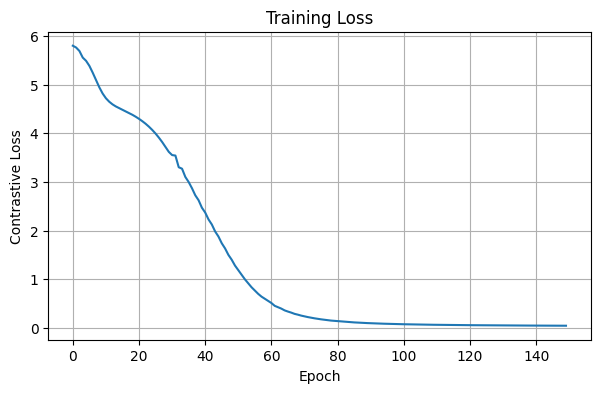

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.grid(True)
plt.show()

#### Cosine Similarity Matrix

In [8]:
img_model.eval()
txt_model.eval()

with torch.no_grad():
    czi = img_model(img_tensor)
    czt = txt_model(txt_tensor)

    czi = F.normalize(czi, p=2, dim=1)
    czt = F.normalize(czt, p=2, dim=1)

    cos_sim_matrix = torch.matmul(czi, czt.T).cpu().numpy()

print("Cosine similarity matrix shape:", cos_sim_matrix.shape)

Cosine similarity matrix shape: (300, 300)


#### Heat Map

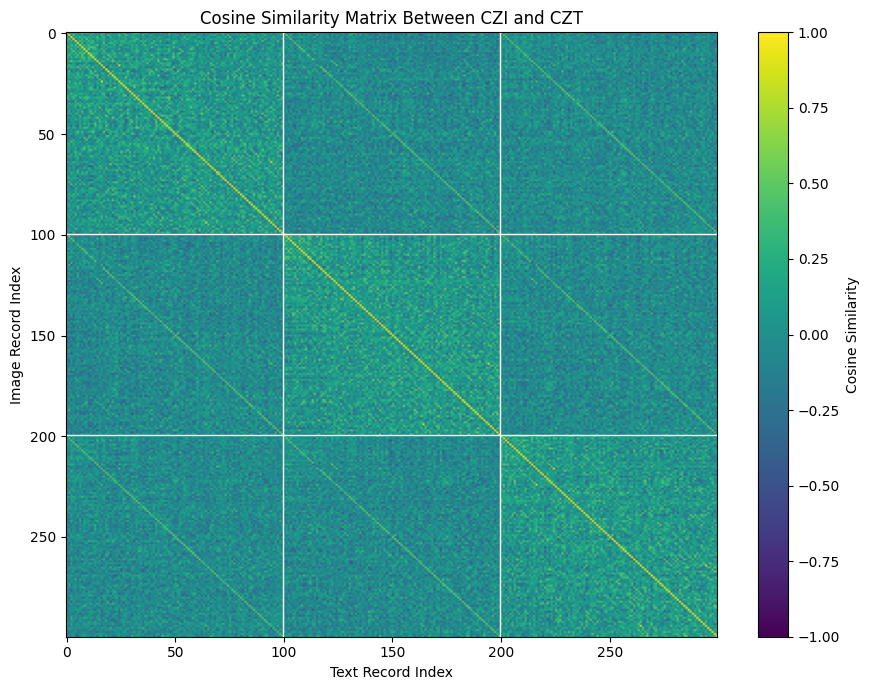

In [9]:
plt.figure(figsize=(9, 7))
plt.imshow(cos_sim_matrix, cmap="viridis", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Cosine Similarity")
plt.title("Cosine Similarity Matrix Between CZI and CZT")
plt.xlabel("Text Record Index")
plt.ylabel("Image Record Index")

# optional separators if data is grouped by 100 samples per class
for pos in [100, 200]:
    plt.axhline(pos - 0.5, color='white', linewidth=1)
    plt.axvline(pos - 0.5, color='white', linewidth=1)

plt.tight_layout()
plt.show()

#### Matching Accuracy

In [10]:
pred_match = np.argmax(cos_sim_matrix, axis=1)
pair_accuracy = np.mean(pred_match == np.arange(N))
print(f"Pair retrieval accuracy (image -> correct text): {pair_accuracy*100:.2f}%")

Pair retrieval accuracy (image -> correct text): 98.00%
